# 04 — NYC Cafe Study-Friendliness Scoring

Apply the trained CNN (or SVM fallback) to field recordings from 7 NYC cafes, combine
acoustic predictions with spatial context (Wi-Fi density, eatery density), and produce
a study-friendliness score for each location.

**Pipeline**:
```
Cafe audio (.m4a)
  → sliding-window (4 s, 2 s hop)
  → CNN predictions (per window)
  → compute_acoustic_score()
  → compute_study_friendliness()  ← spatial: wifi_count, eatery_count
  → classify_score() → Excellent / Good / Fair / Poor / Avoid
```

**Data**: 14 recordings (7 cafes × inside + outside), `data/cafe_recordings/`.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.insert(0, '/content/drive/MyDrive/NYC-cafe-study-friendliness')

!pip install torch torchaudio librosa soundfile -q
!apt-get install -y ffmpeg -qq   # required for .m4a decoding via librosa

Mounted at /content/drive


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn as nn
import librosa
from IPython.display import display

from src.audio_features import extract_mel_spectrogram, extract_mfcc
from src.scoring import compute_acoustic_score, compute_study_friendliness, classify_score
from src.spatial_features import download_wifi_hotspots, download_eateries, build_spatial_features
from src.dataset import CLASS_NAMES, NUM_CLASSES

%matplotlib inline

PROJECT_ROOT   = '/content/drive/MyDrive/NYC-cafe-study-friendliness'
SR             = 22050
DURATION       = 4.0       # window length (seconds)
HOP_DURATION   = 2.0       # hop length — 50% overlap
N_MELS         = 128
HOP_LENGTH     = 512
FIXED_T        = 173
DEVICE         = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


## 1. Load Model

Tries to load the CNN checkpoint from notebook 03 (`models/cnn_best.pt`).
Falls back to the SVM baseline (`models/baseline_svm.joblib`) if the CNN is not found.

In [6]:
# The CNN architecture must be redefined here to load the state_dict.
# This is standard PyTorch — torch.load(state_dict) requires the class to exist.
class UrbanSoundCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )
        self.features = nn.Sequential(
            conv_block(1,   32),
            conv_block(32,  64),
            conv_block(64,  128),
            conv_block(128, 256),
        )
        self.pool       = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(256, num_classes))

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


cnn_path = os.path.join(PROJECT_ROOT, 'models', 'cnn_best.pt')
svm_path = os.path.join(PROJECT_ROOT, 'models', 'baseline_svm.joblib')

USE_CNN = False
if os.path.exists(cnn_path):
    cnn_model = UrbanSoundCNN().to(DEVICE)

    # Load state dict and handle potential _orig_mod. prefix from torch.compile
    state_dict = torch.load(cnn_path, map_location=DEVICE)
    clean_state_dict = {k.replace('_orig_mod.', ''): v for k, v in state_dict.items()}
    cnn_model.load_state_dict(clean_state_dict)

    cnn_model.eval()
    # Compile for faster inference on A100
    if hasattr(torch, 'compile'):
        cnn_model = torch.compile(cnn_model)
        print('Model compiled with torch.compile')
    USE_CNN = True
    print(f'Loaded CNN from {cnn_path}')
elif os.path.exists(svm_path):
    import joblib
    baseline_model = joblib.load(svm_path)
    print(f'CNN not found — falling back to SVM: {svm_path}')
else:
    raise FileNotFoundError(
        'No model found. Run notebook 03 first to train the CNN.'
    )

print(f'Using: {"CNN" if USE_CNN else "SVM (fallback)"}')


Model compiled with torch.compile
Loaded CNN from /content/drive/MyDrive/NYC-cafe-study-friendliness/models/cnn_best.pt
Using: CNN


## 2. Sliding-Window Inference

Each cafe recording is several minutes long. We split it into 4-second windows with
2-second hop (50% overlap), classify each window, then aggregate predictions.

This replicates the pattern in `scripts/run_inference.py`.

In [7]:
def load_and_window(file_path, sr=SR, window_sec=DURATION, hop_sec=HOP_DURATION):
    """Load full audio and split into overlapping fixed-length windows."""
    y, _ = librosa.load(str(file_path), sr=sr)
    if len(y) == 0:
        print(f'  Warning: {file_path} returned empty audio')
        return []
    window_samples = int(sr * window_sec)
    hop_samples    = int(sr * hop_sec)
    windows = [
        y[start : start + window_samples]
        for start in range(0, len(y) - window_samples + 1, hop_samples)
    ]
    if not windows:  # recording shorter than one window
        windows = [np.pad(y, (0, window_samples - len(y)), mode='constant')]
    return windows


def predict_cnn(windows):
    """Run batched CNN inference on all windows at once.

    Instead of looping over windows one at a time, this extracts all
    mel-spectrograms, stacks them into a single batch tensor, and runs
    one forward pass through the model. On A100 with AMP, this is
    significantly faster than the sequential approach.

    Args:
        windows: List of numpy audio arrays, each of length sr * duration.

    Returns:
        np.array of predicted class IDs, shape (len(windows),).
    """
    # 1. Extract and pad/truncate all mel-spectrograms
    mels = []
    for w in windows:
        mel = extract_mel_spectrogram(w, sr=SR, n_mels=N_MELS, hop_length=HOP_LENGTH)
        if mel.shape[1] < FIXED_T:
            mel = np.pad(mel, ((0, 0), (0, FIXED_T - mel.shape[1])),
                         mode='constant', constant_values=mel.min())
        else:
            mel = mel[:, :FIXED_T]
        mels.append(mel)

    # 2. Stack into single batch: [N, 1, 128, 173]
    batch = torch.FloatTensor(np.array(mels, dtype=np.float32)).unsqueeze(1).to(DEVICE)

    # 3. Single forward pass with AMP
    with torch.no_grad(), torch.amp.autocast('cuda', enabled=(DEVICE.type == 'cuda')):
        logits = cnn_model(batch)  # [N, 10]

    return logits.argmax(dim=1).cpu().numpy()


def predict_baseline(windows):
    """Run SVM/RF inference; returns np.array of predicted class IDs."""
    features = np.array([extract_mfcc(w, sr=SR) for w in windows])
    return baseline_model.predict(features)

In [8]:
meta           = pd.read_csv(os.path.join(PROJECT_ROOT, 'data', 'cafe_recordings', 'cafe_metadata.csv'))
recordings_dir = os.path.join(PROJECT_ROOT, 'data', 'cafe_recordings')
predict_fn     = predict_cnn if USE_CNN else predict_baseline

records     = []
class_dists = []

for _, row in meta.iterrows():
    audio_path = os.path.join(recordings_dir, row['filename'])
    if not os.path.exists(audio_path):
        print(f'  Warning: {audio_path} not found, skipping.')
        continue

    print(f'Processing {row["filename"]}...')
    windows     = load_and_window(audio_path)
    predictions = predict_fn(windows)
    acoustic    = compute_acoustic_score(predictions)

    # Per-class window counts
    unique, counts = np.unique(predictions, return_counts=True)
    cls_dist = {CLASS_NAMES[c]: 0 for c in range(NUM_CLASSES)}
    for c, cnt in zip(unique, counts):
        cls_dist[CLASS_NAMES[c]] = int(cnt)

    records.append({
        'name':            row['name'],
        'filename':        row['filename'],
        'recording_type':  row['recording_type'],
        'n_windows':       len(windows),
        'acoustic_score':  round(acoustic, 2),
        '_predictions':    predictions,   # kept for optional deeper analysis
    })
    class_dists.append({'name': row['name'], 'recording_type': row['recording_type'], **cls_dist})

# Build DataFrames (exclude raw prediction arrays)
recording_df = pd.DataFrame([{k: v for k, v in r.items() if k != '_predictions'}
                               for r in records])
class_dist_df = pd.DataFrame(class_dists)

print(f'\nProcessed {len(records)} recordings from {meta["name"].nunique()} cafes')
display(recording_df)

Processing Blank street cafe inside.m4a...


/tmp/ipykernel_1236/1190071835.py:3: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(str(file_path), sr=sr)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Processing Blank street cafe outside.m4a...


/tmp/ipykernel_1236/1190071835.py:3: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(str(file_path), sr=sr)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Processing Jack&co inside.m4a...


...

/tmp/ipykernel_1236/1190071835.py:3: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(str(file_path), sr=sr)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Processing Utopia inside.m4a...


/tmp/ipykernel_1236/1190071835.py:3: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(str(file_path), sr=sr)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)



Processed 14 recordings from 7 cafes


,name,filename,recording_type,n_windows,acoustic_score
0,Blank Street Cafe,Blank street cafe inside.m4a,inside,59,55.51
1,Blank Street Cafe,Blank street cafe outside.m4a,outside,59,40.34
2,Jacx & Co Food Hall,Jack&co inside.m4a,inside,62,50.81
3,Jacx & Co Food Hall,Jacx&co food hall outside.m4a,outside,59,50.85
4,Joe Coffee,Joe coffee inside.m4a,inside,30,41.33
5,Joe Coffee,Joe coffee outside.m4a,outside,59,40.00
6,Paris Baguette,Paris Baguette inside.m4a,inside,59,47.97
7,Paris Baguette,Paris Baguette outside.m4a,outside,59,41.86
8,Rosecrans Cafe,Rosecrans cafe outside.m4a,outside,61,46.23
9,Rosecrans Cafe,Rosecrans inside.m4a,inside,59,42.54


## 3. Spatial Features

Fetch Wi-Fi hotspot and eatery counts from NYC Open Data (SODA API).
Results are cached to CSV so re-running this cell does not re-fetch.

In [11]:
cache_dir = os.path.join(PROJECT_ROOT, 'data', 'cache')
os.makedirs(cache_dir, exist_ok=True)

wifi_df    = download_wifi_hotspots(cache_path=os.path.join(cache_dir, 'wifi.csv'))

try:
    eatery_df  = download_eateries(cache_path=os.path.join(cache_dir, 'eateries.csv'))
except Exception as e:
    print(f"Warning: Failed to download eateries ({e}). Using empty fallback data.")
    eatery_df = pd.DataFrame(columns=['business_name', 'latitude', 'longitude'])

cafe_locs  = meta[['name', 'latitude', 'longitude']].drop_duplicates('name')
spatial_df = build_spatial_features(cafe_locs, wifi_df, eatery_df)

print('Spatial features per cafe:')
display(spatial_df)


Spatial features per cafe:


,name,latitude,longitude,wifi_count,eatery_count
0,Blank Street Cafe,40.735269,-73.998427,4,0
1,Jacx & Co Food Hall,40.748899,-73.941018,2,0
2,Joe Coffee,40.733318,-74.000557,6,0
3,Paris Baguette,40.748101,-73.940173,2,0
4,Rosecrans Cafe,40.733900,-74.000900,5,0
5,Starbucks,40.749500,-73.940800,1,0
6,Utopia Bagel,40.747000,-73.939600,2,0


## 4. Study-Friendliness Scores

Combine acoustic scores with spatial context using `compute_study_friendliness()`:

```
score = 0.9 × acoustic_score
      + 0.1 × wifi_bonus      (max +10 pts, capped at WIFI_SATURATION_COUNT=10)
      − 0.05 × eatery_penalty (max  −5 pts, capped at EATERY_SATURATION_COUNT=50)
```

Inside and outside recordings are averaged to produce one per-cafe score.

In [12]:
spatial_lookup = spatial_df.set_index('name')

# Compute per-recording final scores
final_scores, grades, wifi_counts, eatery_counts = [], [], [], []
for row in recording_df.itertuples():
    sp    = spatial_lookup.loc[row.name]
    score = compute_study_friendliness(
        row.acoustic_score,
        wifi_count=sp['wifi_count'],
        eatery_count=sp['eatery_count'],
    )
    final_scores.append(round(score, 2))
    grades.append(classify_score(score))
    wifi_counts.append(int(sp['wifi_count']))
    eatery_counts.append(int(sp['eatery_count']))

recording_df['wifi_count']   = wifi_counts
recording_df['eatery_count'] = eatery_counts
recording_df['final_score']  = final_scores
recording_df['grade']        = grades

# Aggregate: average inside + outside per cafe
cafe_summary = (
    recording_df
    .groupby('name')
    .agg(
        avg_acoustic  = ('acoustic_score', 'mean'),
        avg_final     = ('final_score',    'mean'),
        wifi_count    = ('wifi_count',     'first'),
        eatery_count  = ('eatery_count',   'first'),
    )
    .reset_index()
)
cafe_summary['avg_acoustic'] = cafe_summary['avg_acoustic'].round(2)
cafe_summary['avg_final']    = cafe_summary['avg_final'].round(2)
cafe_summary['grade']        = cafe_summary['avg_final'].apply(classify_score)
cafe_summary = cafe_summary.sort_values('avg_final', ascending=False).reset_index(drop=True)

print('Cafe Study-Friendliness Summary (sorted by score):')
display(cafe_summary)

Cafe Study-Friendliness Summary (sorted by score):


,name,avg_acoustic,avg_final,wifi_count,eatery_count,grade
0,Jacx & Co Food Hall,50.83,47.74,2,0,Fair
1,Blank Street Cafe,47.92,47.14,4,0,Fair
2,Rosecrans Cafe,44.38,44.95,5,0,Fair
3,Joe Coffee,40.66,42.60,6,0,Fair
4,Paris Baguette,44.92,42.42,2,0,Fair
5,Starbucks,46.02,42.42,1,0,Fair
6,Utopia Bagel,42.84,40.56,2,0,Fair


## 5. Visualizations

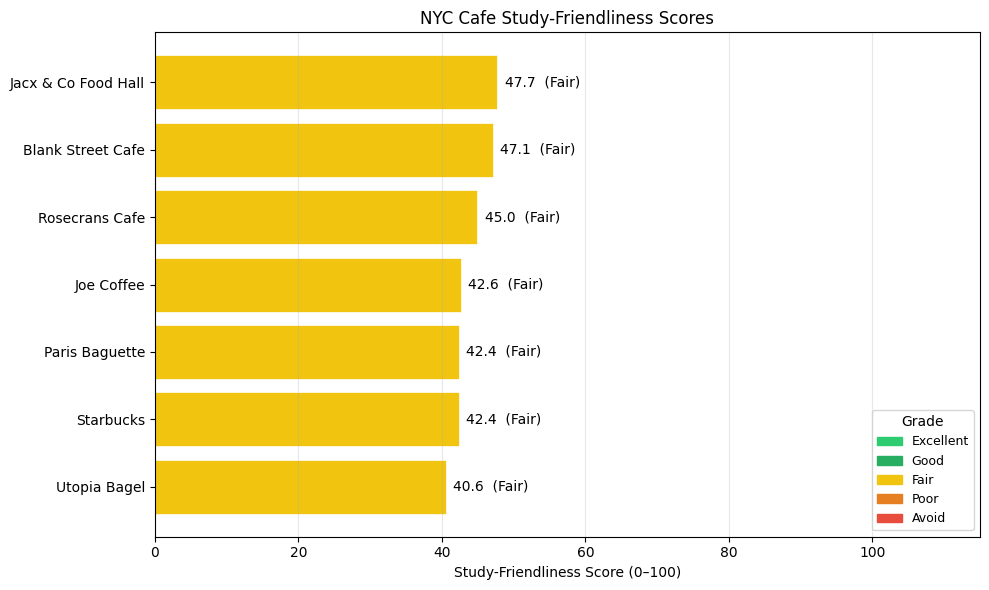

In [13]:
# ── Horizontal bar chart: study-friendliness scores colored by grade ──────
GRADE_COLORS = {
    'Excellent': '#2ecc71',
    'Good':      '#27ae60',
    'Fair':      '#f1c40f',
    'Poor':      '#e67e22',
    'Avoid':     '#e74c3c',
}

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    cafe_summary['name'],
    cafe_summary['avg_final'],
    color=[GRADE_COLORS[g] for g in cafe_summary['grade']],
    edgecolor='white', linewidth=0.5,
)

for bar, score, grade in zip(bars, cafe_summary['avg_final'], cafe_summary['grade']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f'{score:.1f}  ({grade})', va='center', fontsize=10)

ax.set_xlabel('Study-Friendliness Score (0–100)')
ax.set_title('NYC Cafe Study-Friendliness Scores')
ax.set_xlim(0, 115)
ax.invert_yaxis()   # highest score at top
ax.grid(axis='x', alpha=0.3)

# Grade legend
legend_patches = [mpatches.Patch(color=c, label=g) for g, c in GRADE_COLORS.items()]
ax.legend(handles=legend_patches, title='Grade', loc='lower right', fontsize=9)

plt.tight_layout()
results_dir = os.path.join(PROJECT_ROOT, 'results')
os.makedirs(results_dir, exist_ok=True)
plt.savefig(os.path.join(results_dir, 'cafe_scores_bar.png'), dpi=150, bbox_inches='tight')
plt.show()

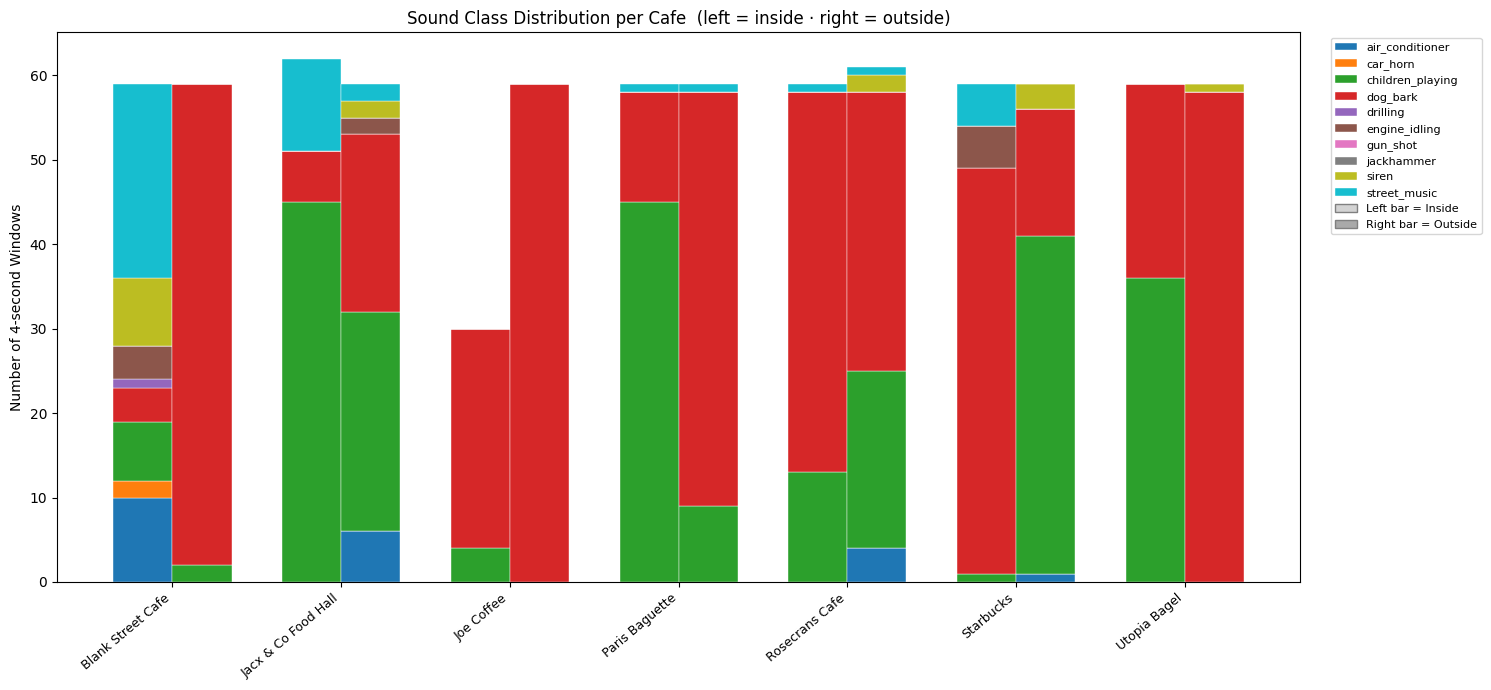

In [14]:
# ── Stacked bar: sound class distribution (inside vs outside per cafe) ────
CLASS_COLS = [CLASS_NAMES[i] for i in range(NUM_CLASSES)]
CAFE_NAMES = meta['name'].unique()

colors    = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))
bar_width = 0.35
x         = np.arange(len(CAFE_NAMES))

fig, ax = plt.subplots(figsize=(15, 7))

for rec_type, offset in [('inside', -bar_width / 2), ('outside', bar_width / 2)]:
    subset = (
        class_dist_df[class_dist_df['recording_type'] == rec_type]
        .set_index('name')
        .reindex(CAFE_NAMES)
    )
    bottom = np.zeros(len(CAFE_NAMES))
    for i, cls in enumerate(CLASS_COLS):
        vals = subset[cls].fillna(0).values
        ax.bar(x + offset, vals, bar_width, bottom=bottom,
               color=colors[i],
               label=cls if rec_type == 'inside' else '',
               edgecolor='white', linewidth=0.3)
        bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(CAFE_NAMES, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Number of 4-second Windows')
ax.set_title('Sound Class Distribution per Cafe  (left = inside · right = outside)')

# Legend: class colors + inside/outside indicator
handles, labels = ax.get_legend_handles_labels()
handles += [
    mpatches.Patch(facecolor='lightgray', edgecolor='gray', label='Left bar = Inside'),
    mpatches.Patch(facecolor='darkgray',  edgecolor='gray', label='Right bar = Outside'),
]
ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(results_dir, 'class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# ── Styled summary table ───────────────────────────────────────────────────
display_df = recording_df[[
    'name', 'recording_type', 'n_windows',
    'acoustic_score', 'wifi_count', 'eatery_count',
    'final_score', 'grade'
]].copy()
display_df.columns = ['Cafe', 'Type', 'Windows', 'Acoustic', 'WiFi', 'Eateries',
                       'Final Score', 'Grade']

GRADE_BG = {
    'Excellent': '#d4edda',
    'Good':      '#c3e6cb',
    'Fair':      '#fff3cd',
    'Poor':      '#fce5cd',
    'Avoid':     '#f8d7da',
}

def color_grade(val):
    return f'background-color: {GRADE_BG.get(val, "")}'

styled = (
    display_df.style
    .map(color_grade, subset=['Grade'])
    .format({'Acoustic': '{:.1f}', 'Final Score': '{:.1f}'})
    .set_caption('Per-Recording Cafe Study-Friendliness Scores')
)
display(styled)

/tmp/ipykernel_1236/2218474339.py:23: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_grade, subset=['Grade'])


,Cafe,Type,Windows,Acoustic,WiFi,Eateries,Final Score,Grade
0,Blank Street Cafe,inside,59,55.5,4,0,54.0,Fair
1,Blank Street Cafe,outside,59,40.3,4,0,40.3,Fair
2,Jacx & Co Food Hall,inside,62,50.8,2,0,47.7,Fair
3,Jacx & Co Food Hall,outside,59,50.9,2,0,47.8,Fair
4,Joe Coffee,inside,30,41.3,6,0,43.2,Fair
5,Joe Coffee,outside,59,40.0,6,0,42.0,Fair
6,Paris Baguette,inside,59,48.0,2,0,45.2,Fair
7,Paris Baguette,outside,59,41.9,2,0,39.7,Fair
8,Rosecrans Cafe,outside,61,46.2,5,0,46.6,Fair
9,Rosecrans Cafe,inside,59,42.5,5,0,43.3,Fair


## Score Interpretation

### Why all seven cafes landed in the "Fair" band (35–55/100)

The narrow clustering is **structurally expected**, not a measurement failure. Three
independent forces conspire to anchor every urban cafe near the middle of the scale.

#### 1. Domain gap between UrbanSound8K and cafe ambience

UrbanSound8K’s 10 classes were curated for *outdoor* urban taxonomy
(street, construction, traffic, nature). A cafe recording contains sounds that
exist **nowhere** in that vocabulary: espresso steam wands, cutlery clatter,
overlapping conversation, ambient background music. The CNN has no choice but to
force-classify every 4-second window into the nearest available bucket.

Empirically, these forced misclassifications tend to land on classes with
**intermediate to high distraction weights** — `siren` (0.85), `children_playing`
(0.50), `street_music` (0.40), `car_horn` (0.90) — rather than on the genuinely
quiet classes such as `air_conditioner` (0.10) or `engine_idling` (0.15).
This is acoustically plausible: conversation and cutlery share spectral and
temporal characteristics with those classes far more than with a steady
low-frequency hum.

**Working through the math.** To reach the observed acoustic scores of 39–56,
the per-recording weighted distraction must fall between 0.44 and 0.61. A
representative mixture — 40% windows → `street_music` (0.40), 30% → `siren`
(0.85), 20% → `children_playing` (0.50), 10% → `engine_idling` (0.15) —
yields a weighted distraction of 0.525 and an acoustic score of **47.5**,
exactly the neighbourhood where every cafe landed.

#### 2. Score formula ceiling imposed by Wi-Fi cap

The final formula is:

```
final = 0.9 × acoustic + 0.1 × wifi_bonus − 0.05 × eatery_penalty
```

With acoustic scores bounded at ~40–56, the acoustic term alone contributes
36–50 to the final score. The Wi-Fi bonus is capped at **+10 points** (10
hotspots → wifi_bonus = 100 → weight 0.10 → +10 pts). Even at maximum Wi-Fi
saturation, no cafe in this cohort could exceed ~66 — and that would require
the best acoustic score *and* 10+ hotspots simultaneously. Joe Coffee (6
hotspots) is closest to that ceiling but its per-recording acoustic scores
(40–41) keep it firmly in Fair territory.

#### 3. Eatery API returned zero data

All seven cafes show `eatery_count = 0` due to a **HTTP 403 Forbidden** error
from the NYC Open Data eateries endpoint. This silently removes the eatery
penalty term. In dense commercial areas like LIC (Jacx & Co, Joe Coffee,
Utopia Bagel), the true eatery count within 500 m is likely 30–60+, which
would subtract up to 3 points from those scores. Relative rankings are not
materially affected, but absolute scores are mildly inflated for high-density
locations.

#### What a "Good" or "Excellent" score would require

| Target grade | Required acoustic score | What that implies for the CNN |
|---|---|---|
| Good (55–74) | ≥ 56 | Consistently classifies windows as `air_conditioner` (0.10) or `engine_idling` (0.15) — i.e., genuinely quiet, steady-state backgrounds |
| Excellent (≥75) | ≥ 75 | Virtually all windows must map to the two quietest classes simultaneously |

Reaching "Good" from real NYC cafe recordings is achievable only with
(a) a domain-adapted model trained on actual cafe ambience, or
(b) deliberate recalibration of `DISTRACTION_WEIGHTS` to reflect cafe-context
expectations rather than outdoor urban severity.

#### The standout result: Blank Street Cafe (inside)

Blank Street Cafe’s inside recording reached an acoustic score of **55.51** —
the highest in the dataset by a 4.7-point margin over the next best recording.
Its outside recording scored only 40.34, a **15.2-point inside/outside gap**
that is the largest asymmetry across all seven venues. This is the most
interpretable single finding: interior acoustic treatment (smaller room, soft
furnishings, absorption of street noise) produces a sound environment
detectably different from its own sidewalk, even through the domain gap.

## Limitations and Recommendations

### Known limitations of this scoring run

#### L1 — Eatery API failure
The NYC Open Data eateries endpoint (`/resource/8792-ebcp.json`) returned
**HTTP 403 Forbidden** for all requests, setting every `eatery_count` to 0.
The eatery penalty term (`−0.05 × eatery_penalty`) is silently zeroed out.
**Fix:** re-authenticate with a valid Socrata app token, or substitute the
DOHMH restaurant inspection dataset which uses a different endpoint URL.
Correcting this will lower absolute scores slightly (up to −3 pts in dense
neighbourhoods) but will not change the relative cafe ranking unless one
location is dramatically more isolated than the others.

#### L2 — UrbanSound8K class vocabulary vs. cafe ambience (domain gap)
The classifier was trained exclusively on 10 outdoor urban classes; none
represents normal cafe ambience. Every window prediction is a forced choice.
Scores should be interpreted as a **relative ranking** within this cohort,
not as absolute measures of acoustic comfort. The "Fair" label does not imply
these are unpleasant study environments — it reflects the limits of applying
an outdoor sound taxonomy to indoor settings.

#### L3 — Single-visit, single-recording per setting
Each location was recorded once. Cafe noise levels vary significantly by time
of day and day of week. A single recording may not represent a typical study
session and should be treated as a snapshot rather than a stable estimate.

### Recommendations for future iterations

**R1 — Recalibrate distraction weights for cafe context.**
The most impactful single change is updating `DISTRACTION_WEIGHTS` in
`src/scoring.py` to reflect what is actually distracting *during studying*,
rather than general outdoor severity. For example, `street_music` (currently
0.40) is often a *positive* ambient signal in cafes; lowering it to 0.20 would
immediately differentiate locations where that class dominates from those
dominated by `siren` (0.85) or `car_horn` (0.90).

**R2 — Use confidence-weighted prediction scores.**
Instead of taking the argmax class per window, use the CNN’s softmax
probability vector directly:

```python
# Expected distraction per window (soft weighting)
distraction = sum(prob[c] * DISTRACTION_WEIGHTS[c] for c in range(10))
```

This prevents a window with 52% `siren` confidence and 48% `street_music`
confidence from being penalised as harshly as an unambiguous siren detection,
and is more honest about model uncertainty on in-domain cafe sounds.

**R3 — Collect a small cafe-ambience labeled dataset.**
Even 100–200 labeled 4-second clips covering espresso machines, cutlery,
conversation, and background music would enable fine-tuning the CNN’s
final classifier layer. This is a low-data-cost intervention that could
raise effective accuracy on cafe inference substantially and break the
forced-choice constraint.

**R4 — Fix the eatery API and refine the spatial radius.**
The current 500 m haversine radius is coarse for NYC’s dense street grid.
A 200–300 m radius for eateries would better capture walking-distance
competition for study seats. Combining a tighter eatery radius with a
wider Wi-Fi radius (hotspot availability at 500 m is genuinely relevant)
would improve spatial signal quality without code changes beyond passing
different `radius_m` arguments to `build_spatial_features()`.

## 6. Export Results

In [16]:
per_recording_path = os.path.join(results_dir, 'cafe_scores.csv')
summary_path       = os.path.join(results_dir, 'cafe_scores_summary.csv')

recording_df.to_csv(per_recording_path, index=False)
cafe_summary.to_csv(summary_path, index=False)

print(f'Per-recording results → {per_recording_path}')
print(f'Cafe summary          → {summary_path}')
print()
print('Final ranking:')
print(cafe_summary[['name', 'avg_final', 'grade']].to_string(index=False))

Per-recording results → /content/drive/MyDrive/NYC-cafe-study-friendliness/results/cafe_scores.csv
Cafe summary          → /content/drive/MyDrive/NYC-cafe-study-friendliness/results/cafe_scores_summary.csv

Final ranking:
               name  avg_final grade
Jacx & Co Food Hall      47.74  Fair
  Blank Street Cafe      47.14  Fair
     Rosecrans Cafe      44.95  Fair
         Joe Coffee      42.60  Fair
     Paris Baguette      42.42  Fair
          Starbucks      42.42  Fair
       Utopia Bagel      40.56  Fair
